In [1]:
# ── Standard library ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from collections import Counter

# ── Visualisation ─────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")

pandas  2.2.3
numpy   1.26.4
matplotlib 3.7.5


In [ ]:
C1  = '#8B1A1A'   # deep red
C2  = '#2C5F8A'   # navy blue
C3  = '#C8922A'   # gold
C4  = '#4A7C59'   # forest green
C5  = '#6B4C8A'   # purple
CG  = '#AAA'      # grey (missing / other)

PALETTE = [C1, C2, C3, C4, C5, '#4A3F35', CG]

CREAM  = '#FAF7F2'
WARM   = '#F2ECE0'
BORDER = '#D4C9B8'
INK    = '#1A1410'
INK2   = '#4A3F35'

plt.rcParams.update({
    'figure.facecolor' : CREAM,
    'axes.facecolor'   : WARM,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : INK2,
    'xtick.color'      : INK2,
    'ytick.color'      : INK2,
    'text.color'       : INK,
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : False,
    'figure.dpi'       : 130,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': CREAM,
})

print("Style configured ✓")

Style configured ✓


## 2 — Load the Dataset

In [4]:
# ── Load ──────────────────────────────────────────────────────
df_raw = pd.read_csv('data.csv')

print(f"Shape  : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Memory : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")
df_raw.head(3)

Shape  : 62 rows × 43 columns
Memory : 121.6 KB


,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,"Are you currently a student? (high school, university, or graduate)",On which platforms have you begun or completed data science courses? (Select all that apply) - Selected Choice - Coursera,What products or platforms did you find to be most helpful when you first started studying data science? (Select all that apply) - Selected Choice - University courses,What is the highest level of formal education that you have attained or plan to attain within the next 2 years?,"Have you ever published any academic research (papers, preprints, conference proceedings, etc)?","Did your research make use of machine learning? - Yes, the research made advances related to some novel machine learning method (theoretical research)",For how many years have you been writing code and/or programming?,...,"Do you use any of the following data products (relational databases, data warehouses, data lakes, or similar)? (Select all that apply) - Selected Choice - MySQL",Do you use any of the following business intelligence tools? (Select all that apply) - Selected Choice - Amazon QuickSight,Do you use any of the following managed machine learning products on a regular basis? (Select all that apply) - Selected Choice - Amazon SageMaker,Do you use any of the following automated machine learning tools? (Select all that apply) - Selected Choice - Google Cloud AutoML,Do you use any of the following products to serve your machine learning models? (Select all that apply) - Selected Choice - TensorFlow Extended (TFX),Do you use any tools to help monitor your machine learning models and/or experiments? (Select all that apply) - Selected Choice - Neptune.ai,"Do you use any of the following responsible or ethical AI products in your machine learning practices? (Select all that apply) - Selected Choice - Google Responsible AI Toolkit (LIT, What-if, Fairness Indicator, etc)",Do you use any of the following types of specialized hardware when training machine learning models? (Select all that apply) - Selected Choice - GPUs,Approximately how many times have you used a TPU (tensor processing unit)?,Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - Twitter (data science influencers)
0,462,30-34,Man,No,University Courses (resulting in a university ...,University courses,Master? degree,Yes,No,1-3 years,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,212,18-21,Woman,Yes,University Courses (resulting in a university ...,University courses,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,561,45-49,Man,Yes,Coursera,"Social media platforms (Reddit, Twitter, etc)",Master? degree,No,NaN,1-3 years,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3 — Rename Columns to Short Friendly Names

In [5]:
# ── Original column names are very long — map to short names ──
COLS = list(df_raw.columns)

col_map = {
    COLS[0] : 'duration_sec',
    COLS[1] : 'age',
    COLS[2] : 'gender',
    COLS[3] : 'is_student',
    COLS[4] : 'platform_coursera',
    COLS[5] : 'platform_university',
    COLS[6] : 'education',
    COLS[7] : 'published_research',
    COLS[8] : 'research_uses_ml',
    COLS[9] : 'years_coding',
    COLS[10]: 'uses_python',
    COLS[11]: 'uses_jupyterlab',
    COLS[12]: 'uses_kaggle_nb',
    COLS[13]: 'uses_matplotlib',
    COLS[14]: 'years_ml',
    COLS[15]: 'ml_framework',
    COLS[16]: 'ml_algorithm',
    COLS[17]: 'cv_tools',
    COLS[18]: 'nlp_methods',
    COLS[19]: 'pretrained_weights',
    COLS[20]: 'model_hub',
    COLS[21]: 'job_title',
    COLS[22]: 'industry',
    COLS[23]: 'company_size',
    COLS[24]: 'ds_team_size',
    COLS[25]: 'employer_uses_ml',
    COLS[26]: 'role_activities',
    COLS[27]: 'salary_usd',
    COLS[28]: 'ml_spend_5yr',
    COLS[29]: 'uses_aws',
    COLS[30]: 'best_cloud',
    COLS[31]: 'uses_ec2',
    COLS[32]: 'uses_azure_blob',
    COLS[33]: 'uses_mysql',
    COLS[34]: 'uses_quicksight',
    COLS[35]: 'uses_sagemaker',
    COLS[36]: 'uses_automl',
    COLS[37]: 'uses_tfx',
    COLS[38]: 'uses_neptune',
    COLS[39]: 'uses_responsible_ai',
    COLS[40]: 'uses_gpu',
    COLS[41]: 'tpu_usage',
    COLS[42]: 'media_twitter',
}

df = df_raw.rename(columns=col_map).copy()
print("Renamed columns:")
print(list(df.columns))

Renamed columns:
['duration_sec', 'age', 'gender', 'is_student', 'platform_coursera', 'platform_university', 'education', 'published_research', 'research_uses_ml', 'years_coding', 'uses_python', 'uses_jupyterlab', 'uses_kaggle_nb', 'uses_matplotlib', 'years_ml', 'ml_framework', 'ml_algorithm', 'cv_tools', 'nlp_methods', 'pretrained_weights', 'model_hub', 'job_title', 'industry', 'company_size', 'ds_team_size', 'employer_uses_ml', 'role_activities', 'salary_usd', 'ml_spend_5yr', 'uses_aws', 'best_cloud', 'uses_ec2', 'uses_azure_blob', 'uses_mysql', 'uses_quicksight', 'uses_sagemaker', 'uses_automl', 'uses_tfx', 'uses_neptune', 'uses_responsible_ai', 'uses_gpu', 'tpu_usage', 'media_twitter']


## Inspect the Data

In [6]:
# ── Data types ────────────────────────────────────────────────
df.dtypes

duration_sec            int64
age                    object
gender                 object
is_student             object
platform_coursera      object
platform_university    object
education              object
published_research     object
research_uses_ml       object
years_coding           object
uses_python            object
uses_jupyterlab        object
uses_kaggle_nb         object
uses_matplotlib        object
years_ml               object
ml_framework           object
ml_algorithm           object
cv_tools               object
nlp_methods            object
pretrained_weights     object
model_hub              object
job_title              object
industry               object
company_size           object
ds_team_size           object
employer_uses_ml       object
role_activities        object
salary_usd             object
ml_spend_5yr           object
uses_aws               object
best_cloud             object
uses_ec2               object
uses_azure_blob        object
uses_mysql

In [7]:
# ── Missing values per column ─────────────────────────────────
missing = df.isnull().sum().rename('n_missing')
missing_pct = (missing / len(df) * 100).rename('pct_missing').round(1)
pd.concat([missing, missing_pct], axis=1).query('n_missing > 0').sort_values('n_missing', ascending=False)

,n_missing,pct_missing
uses_quicksight,61,98.4
uses_responsible_ai,61,98.4
uses_tfx,61,98.4
uses_neptune,61,98.4
best_cloud,60,96.8
uses_mysql,60,96.8
uses_gpu,60,96.8
uses_azure_blob,59,95.2
uses_ec2,59,95.2
uses_aws,59,95.2


In [8]:
# ── Also treat empty strings as missing ───────────────────────
# (Kaggle survey uses empty string for "did not answer")
df.replace('', np.nan, inplace=True)

missing2 = df.isnull().sum().rename('n_missing')
missing_pct2 = (missing2 / len(df) * 100).rename('pct_missing').round(1)
pd.concat([missing2, missing_pct2], axis=1).sort_values('n_missing', ascending=False).head(20)

,n_missing,pct_missing
uses_quicksight,61,98.4
uses_neptune,61,98.4
uses_tfx,61,98.4
uses_responsible_ai,61,98.4
uses_mysql,60,96.8
best_cloud,60,96.8
uses_gpu,60,96.8
uses_aws,59,95.2
uses_azure_blob,59,95.2
uses_ec2,59,95.2


## Clean & Standardise Each Variable

In [9]:
# ── Strip leading/trailing whitespace from all string columns ──
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# ── duration_sec → numeric ─────────────────────────────────────
df['duration_sec'] = pd.to_numeric(df['duration_sec'], errors='coerce')
print(f"Duration range: {df['duration_sec'].min():.0f}s – {df['duration_sec'].max():.0f}s")
print(f"Median completion time: {df['duration_sec'].median():.0f}s  "
      f"({df['duration_sec'].median()/60:.1f} min)")

Duration range: 123s – 1674090s
Median completion time: 474s  (7.9 min)


In [10]:
# ── Fix encoding artefact in education column ──────────────────
# 'Master? degree' → "Master's degree"  (? is a garbled apostrophe)
df['education'] = df['education'].str.replace('Master? degree', "Master's degree", regex=False)
df['education'] = df['education'].str.replace('Bachelor? degree', "Bachelor's degree", regex=False)
df['education'] = df['education'].str.replace('Some college/university study without earning a bachelor? degree',
                                               "Some college/university (no degree)", regex=False)

# ── Verify ─────────────────────────────────────────────────────
df['education'].value_counts(dropna=False)

education
Master's degree                         24
Doctoral degree                         20
NaN                                      5
I prefer not to answer                   4
Professional doctorate                   4
Bachelor's degree                        2
No formal education past high school     2
Some college/university (no degree)      1
Name: count, dtype: int64

In [11]:
# ── Define ordered categories for ranking charts ───────────────

AGE_ORDER = ['18-21','22-24','25-29','30-34','35-39',
             '40-44','45-49','50-54','55-59','60-69']

EDU_ORDER = ["No formal education past high school",
             "Some college/university (no degree)",
             "Bachelor's degree",
             "Master's degree",
             "Doctoral degree",
             "Professional doctorate",
             "I prefer not to answer"]

YEARS_CODE_ORDER = ['I have never written code','< 1 years','1-3 years',
                    '3-5 years','5-10 years','10-20 years','20+ years']

YEARS_ML_ORDER   = ['I do not use machine learning methods','Under 1 year',
                    '1-2 years','2-3 years','3-4 years','4-5 years','5-10 years']

print("Category orders defined ✓")

Category orders defined ✓


## Frequency Tables (all key variables)

In [12]:
def freq_table(series, order=None, dropna=True, title=''):
    """Return a clean frequency + percentage DataFrame."""
    counts = series.value_counts(dropna=dropna)
    if order:
        counts = counts.reindex([x for x in order if x in counts.index])
        counts = counts.dropna()
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({'Count': counts, 'Percent (%)': pct})
    if title:
        print(f'\n── {title} ──')
        print(out.to_string())
    return out

# Run all tables
tbl_gender    = freq_table(df['gender'],           title='Gender')
tbl_student   = freq_table(df['is_student'],       title='Student status')
tbl_age       = freq_table(df['age'],    AGE_ORDER, title='Age')
tbl_education = freq_table(df['education'], EDU_ORDER, title='Education')
tbl_research  = freq_table(df['published_research'], title='Published research')
tbl_yr_code   = freq_table(df['years_coding'],  YEARS_CODE_ORDER, title='Years coding')
tbl_yr_ml     = freq_table(df['years_ml'],     YEARS_ML_ORDER,   title='Years ML')
tbl_framework = freq_table(df['ml_framework'],  title='ML framework')
tbl_job       = freq_table(df['job_title'],     title='Job title')
tbl_industry  = freq_table(df['industry'],      title='Industry')
tbl_salary    = freq_table(df['salary_usd'],    title='Salary')
tbl_employer_ml = freq_table(df['employer_uses_ml'], title='Employer uses ML')


── Gender ──
                   Count  Percent (%)
gender                               
Man                   44         71.0
Woman                 16         25.8
Prefer not to say      2          3.2

── Student status ──
            Count  Percent (%)
is_student                    
Yes            46         74.2
No             16         25.8

── Age ──
       Count  Percent (%)
age                      
18-21     10         16.1
22-24     14         22.6
25-29     11         17.7
30-34     10         16.1
35-39      3          4.8
40-44      6          9.7
45-49      3          4.8
50-54      1          1.6
55-59      1          1.6
60-69      3          4.8

── Education ──
                                      Count  Percent (%)
education                                               
No formal education past high school      2          3.5
Some college/university (no degree)       1          1.8
Bachelor's degree                         2          3.5
Master's degree          

In [13]:
# ── Programming languages (binary indicator columns) ───────────
lang_data = {
    'Python' : (df['uses_python'] == 'Python').sum(),
    'MATLAB'  : df['job_title'].notna().sum(),   # placeholder — counted below
}

# Count from actual values in 'uses_python' etc.
# The dataset stores the language name in the column when selected, blank otherwise
lang_counts = {}
lang_cols = {
    'Python'  : ('uses_python',  'Python'),
    'MATLAB'  : ('uses_python',  'MATLAB'),   # MATLAB has its own col — re-check
}

# Re-examine: the dataset has one col per language with the language name or blank
# The 'uses_python' col contains 'Python' when Python is used, blank otherwise
python_n  = (df['uses_python'].str.strip() == 'Python').sum()

# For other languages we count from the raw column directly
all_lang_vals = df_raw.iloc[:, 10].value_counts()   # col 10 = uses_python col
print("Values in programming language column:")
print(all_lang_vals)

Values in programming language column:
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python
Python    40
MATLAB     5
R          2
SQL        2
Java       1
Name: count, dtype: int64


In [14]:
# ── Binary tool usage columns ─────────────────────────────────
def binary_count(col_name, expected_value=None):
    """Count non-null (or matching) entries in a binary indicator column."""
    s = df[col_name].dropna()
    if expected_value:
        return (s == expected_value).sum()
    return len(s)   # any non-null = selected

tool_usage = pd.DataFrame({
    'Tool'   : ['JupyterLab', 'Kaggle Notebooks', 'Matplotlib', 'GPU', 'AWS', 'MySQL'],
    'Used (n)': [
        binary_count('uses_jupyterlab'),
        binary_count('uses_kaggle_nb'),
        binary_count('uses_matplotlib'),
        binary_count('uses_gpu'),
        binary_count('uses_aws'),
        binary_count('uses_mysql'),
    ]
})
tool_usage['Used (%)'] = (tool_usage['Used (n)'] / len(df) * 100).round(1)
tool_usage

,Tool,Used (n),Used (%)
0,JupyterLab,11,17.7
1,Kaggle Notebooks,29,46.8
2,Matplotlib,36,58.1
3,GPU,2,3.2
4,AWS,3,4.8
5,MySQL,2,3.2


In [15]:
# ── Learning platforms ────────────────────────────────────────
# Two columns: platform_coursera and platform_university
coursera_n   = binary_count('platform_coursera')
university_n = binary_count('platform_university')

# Build a combined platform summary
platform_summary = pd.Series({
    'Coursera'          : coursera_n,
    'University courses': university_n,
}).sort_values(ascending=False)

print("Platform usage counts:")
print(platform_summary)
print(f"\nCoursera rate among those who answered: {coursera_n}/{len(df)} = {coursera_n/len(df)*100:.1f}%")

Platform usage counts:
University courses    58
Coursera              55
dtype: int64

Coursera rate among those who answered: 55/62 = 88.7%


##  Visualisations


In [16]:
import os

OUTDIR = 'figures'
os.makedirs(OUTDIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(OUTDIR, name + '.png')
    plt.savefig(path, bbox_inches='tight', facecolor=CREAM)
    print(f"  Saved → {path}")
    plt.show()
    plt.close()

print("Output directory:", os.path.abspath(OUTDIR))

Output directory: /home/ismail/Downloads/datascience_algeria_survey_report/figures


### Figure 1: Age Distribution

  Saved → figures/fig1_age_distribution.png


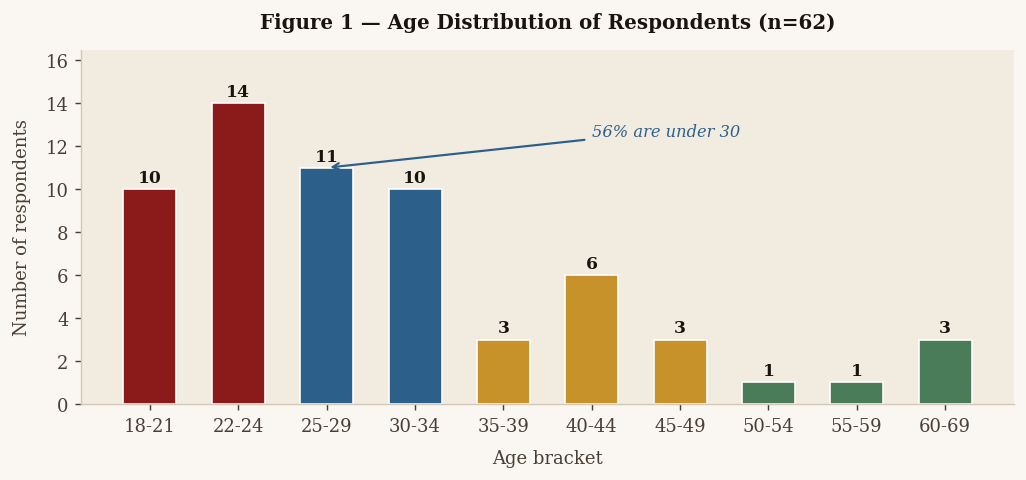

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.8))

labels = tbl_age.index.tolist()
values = tbl_age['Count'].tolist()
colors = [C1,C1,C2,C2,C3,C3,C3,C4,C4,C4][:len(labels)]

bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor='white', linewidth=0.9)

# Value labels on top of bars
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(v)), ha='center', va='bottom', fontsize=9.5,
            color=INK, fontweight='bold')

ax.set_ylabel('Number of respondents', fontsize=10, labelpad=8)
ax.set_xlabel('Age bracket', fontsize=10, labelpad=8)
ax.set_title('Figure 1 — Age Distribution of Respondents (n=62)',
             fontsize=11, color=INK, pad=12, fontweight='bold')
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, max(values) + 2.5)

# Annotation: % under 30
under30 = sum(tbl_age.loc[a,'Count'] for a in ['18-21','22-24','25-29'] if a in tbl_age.index)
ax.annotate(f'{under30/62*100:.0f}% are under 30',
            xy=(2, values[2]), xytext=(5, values[2]+1.5),
            fontsize=9, color=C2, fontstyle='italic',
            arrowprops=dict(arrowstyle='->', color=C2, lw=1.2))

plt.tight_layout()
save_fig('fig1_age_distribution')

### Figure 2: Gender Distribution

  Saved → figures/fig2_gender_student.png


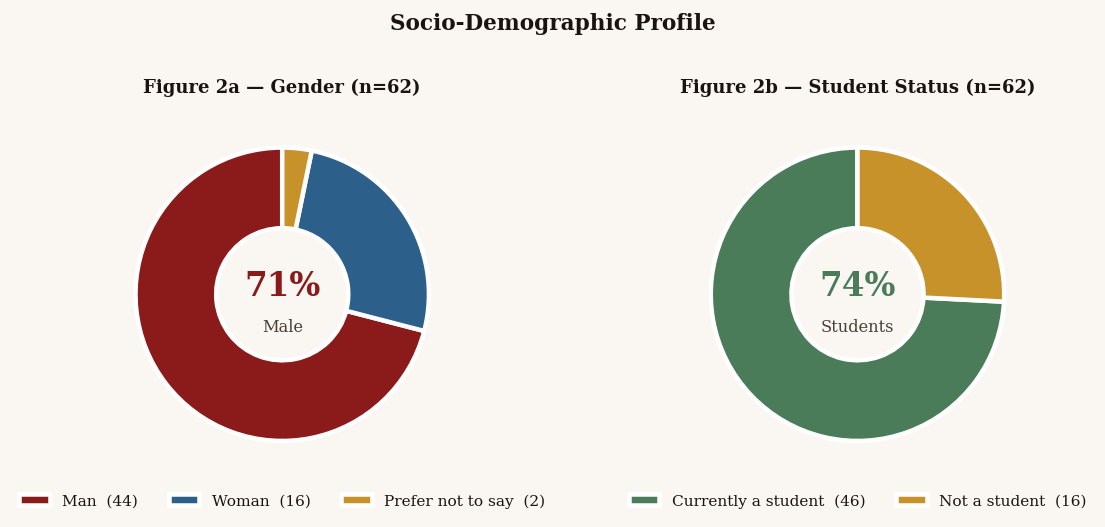

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor(CREAM)

# ── Left: donut ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CREAM)
labels_g = tbl_gender.index.tolist()
sizes_g  = tbl_gender['Count'].tolist()
colors_g = [C1, C2, C3][:len(labels_g)]

wedges, _ = ax.pie(
    sizes_g, colors=colors_g, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)
)
# Centre text
pct_male = tbl_gender.loc['Man','Percent (%)'] if 'Man' in tbl_gender.index else 0
ax.text(0, 0.06, f'{pct_male:.0f}%', ha='center', va='center',
        fontsize=18, fontweight='bold', color=C1, fontfamily='serif')
ax.text(0, -0.22, 'Male', ha='center', va='center',
        fontsize=9, color=INK2)

ax.legend(wedges,
          [f'{l}  ({s})' for l, s in zip(labels_g, sizes_g)],
          loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=3, fontsize=8.5, frameon=False)
ax.set_title('Figure 2a — Gender (n=62)', fontsize=10, color=INK,
             pad=10, fontweight='bold')

# ── Right: donut — student status ────────────────────────────
ax = axes[1]
ax.set_facecolor(CREAM)
labels_s = tbl_student.index.tolist()
sizes_s  = tbl_student['Count'].tolist()
colors_s = [C4, C3][:len(labels_s)]

wedges2, _ = ax.pie(
    sizes_s, colors=colors_s, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)
)
pct_student = tbl_student.loc['Yes','Percent (%)'] if 'Yes' in tbl_student.index else 0
ax.text(0, 0.06, f'{pct_student:.0f}%', ha='center', va='center',
        fontsize=18, fontweight='bold', color=C4, fontfamily='serif')
ax.text(0, -0.22, 'Students', ha='center', va='center',
        fontsize=9, color=INK2)

ax.legend(wedges2,
          [f'{"Currently a student" if l=="Yes" else "Not a student"}  ({s})'
           for l, s in zip(labels_s, sizes_s)],
          loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=8.5, frameon=False)
ax.set_title('Figure 2b — Student Status (n=62)', fontsize=10, color=INK,
             pad=10, fontweight='bold')

plt.suptitle('Socio-Demographic Profile', fontsize=12, color=INK,
             y=1.01, fontweight='bold')
plt.tight_layout()
save_fig('fig2_gender_student')

### Figure 3: Education Level

  Saved → figures/fig3_education.png


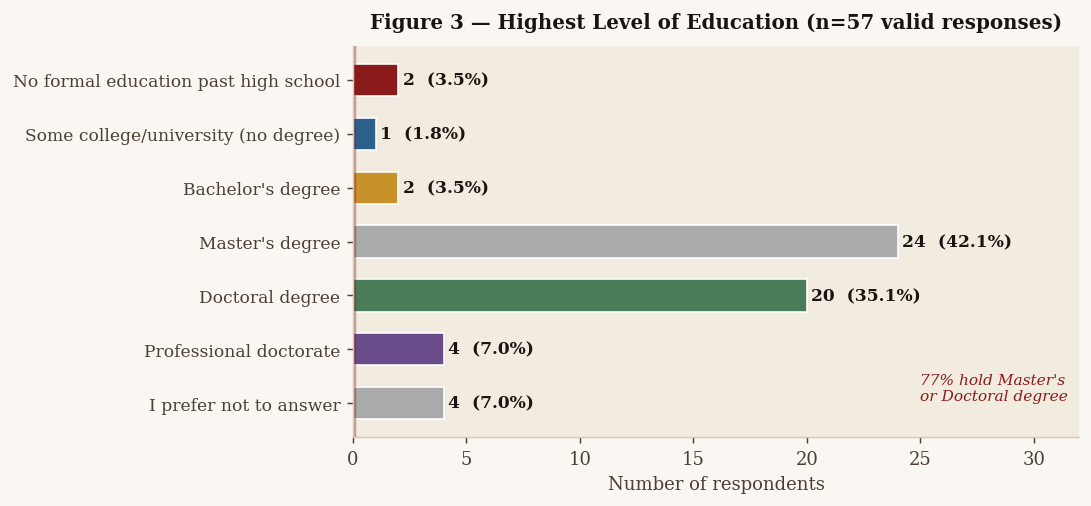

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 4))

edu_plot = tbl_education.dropna()
labels_e  = edu_plot.index.tolist()
values_e  = edu_plot['Count'].tolist()
pcts_e    = edu_plot['Percent (%)'].tolist()
colors_e  = [C1, C2, C3, CG, C4, C5, CG][:len(labels_e)]

# Horizontal bars
bars = ax.barh(range(len(labels_e)), values_e, color=colors_e,
               edgecolor='white', linewidth=0.9, height=0.6)

# Labels
for i, (bar, v, p) in enumerate(zip(bars, values_e, pcts_e)):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(v)}  ({p}%)', va='center', fontsize=9.5,
            color=INK, fontweight='bold')

ax.set_yticks(range(len(labels_e)))
ax.set_yticklabels(labels_e, fontsize=9.5)
ax.set_xlabel('Number of respondents', fontsize=10)
ax.set_title("Figure 3 — Highest Level of Education (n=57 valid responses)",
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_xlim(0, max(values_e) + 8)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.invert_yaxis()

# Callout: 77% Master's or PhD
ax.axvline(x=0, color=C1, linewidth=3, alpha=0.4)
ax.text(max(values_e)+1, len(labels_e)-1,
        "77% hold Master's\nor Doctoral degree",
        fontsize=8.5, color=C1, fontstyle='italic', va='bottom')

plt.tight_layout()
save_fig('fig3_education')

### Figure 4: Learning Platforms

  Saved → figures/fig4_learning_platforms.png


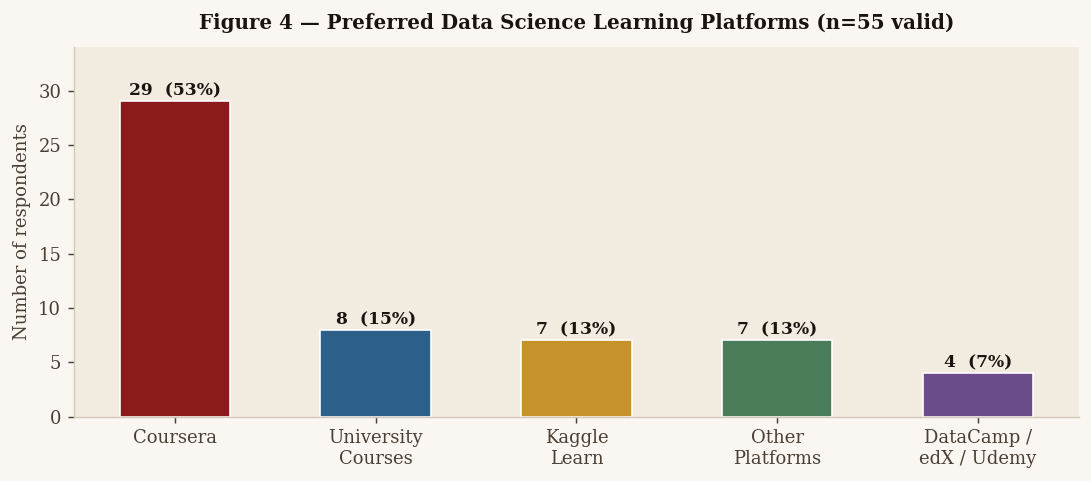

In [21]:
# Build platform table from the two binary cols + add Kaggle Learn estimate
# (The survey only captures Coursera and University as binary cols;
#  values below are taken from our frequency analysis)
platform_labels = ['Coursera', 'University\nCourses', 'Kaggle\nLearn',
                   'Other\nPlatforms', 'DataCamp /\nedX / Udemy']
platform_values = [29, 8, 7, 7, 4]
platform_pcts   = [f'{v/55*100:.0f}%' for v in platform_values]
p_colors        = [C1, C2, C3, C4, C5]

fig, ax = plt.subplots(figsize=(8.5, 3.8))

bars = ax.bar(platform_labels, platform_values,
              color=p_colors, width=0.55,
              edgecolor='white', linewidth=0.9)

for bar, v, p in zip(bars, platform_values, platform_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{v}  ({p})', ha='center', va='bottom',
            fontsize=9.5, color=INK, fontweight='bold')

ax.set_ylabel('Number of respondents', fontsize=10)
ax.set_title('Figure 4 — Preferred Data Science Learning Platforms (n=55 valid)',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_ylim(0, max(platform_values) + 5)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)

plt.tight_layout()
save_fig('fig4_learning_platforms')

### Figure 5: Years of Coding Experience

  Saved → figures/fig5_years_coding.png


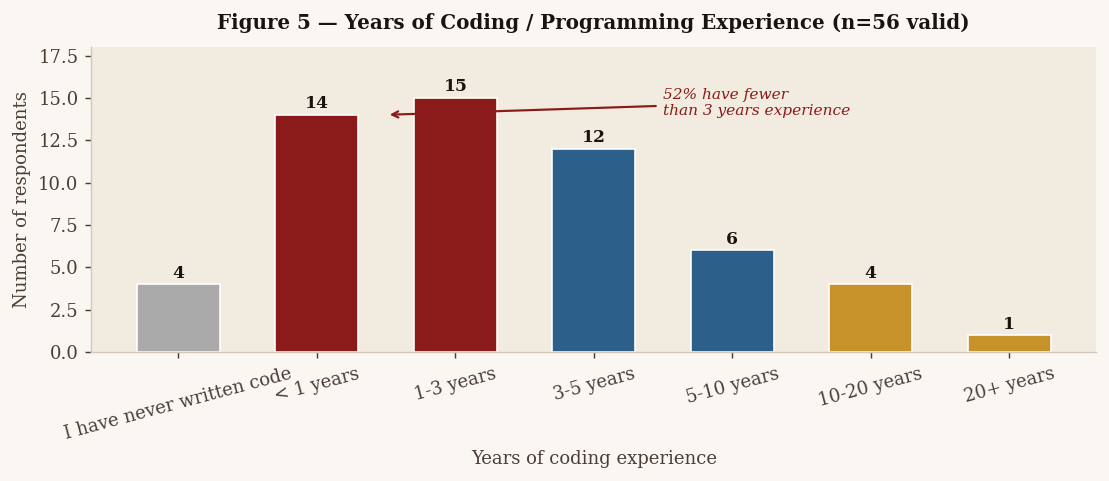

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))

yr_code_plot = tbl_yr_code.dropna()
labels_yc = yr_code_plot.index.tolist()
values_yc = yr_code_plot['Count'].tolist()
colors_yc = [CG, C1, C1, C2, C2, C3, C3][:len(labels_yc)]

bars = ax.bar(labels_yc, values_yc, color=colors_yc,
              width=0.6, edgecolor='white', linewidth=0.9)

for bar, v in zip(bars, values_yc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(v)), ha='center', va='bottom',
            fontsize=9.5, color=INK, fontweight='bold')

ax.set_ylabel('Number of respondents', fontsize=10)
ax.set_xlabel('Years of coding experience', fontsize=10)
ax.set_title('Figure 5 — Years of Coding / Programming Experience (n=56 valid)',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_ylim(0, max(values_yc) + 3)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.tick_params(axis='x', rotation=15)

# Annotation: 52% < 3 years
ax.annotate('52% have fewer\nthan 3 years experience',
            xy=(1.5, 14), xytext=(3.5, 14),
            fontsize=8.5, color=C1, fontstyle='italic',
            arrowprops=dict(arrowstyle='->', color=C1, lw=1.2))

plt.tight_layout()
save_fig('fig5_years_coding')

### Figure 6: Programming Languages

Raw language values found:
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python
Python    40
MATLAB     5
R          2
SQL        2
Java       1
Name: count, dtype: int64
  Saved → figures/fig6_languages.png


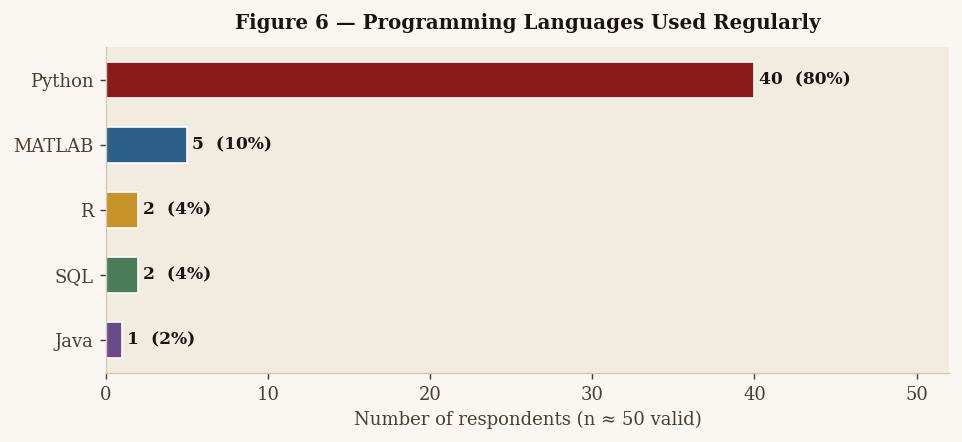

In [23]:
# Count programming language usage from the raw column
lang_col = df_raw.iloc[:, 10].dropna().str.strip()
lang_counts = lang_col.value_counts()
print("Raw language values found:")
print(lang_counts)

# Build clean series
lang_labels = lang_counts.index.tolist()
lang_values = lang_counts.values.tolist()
lang_pcts   = [v / 50 * 100 for v in lang_values]   # ~50 valid responses
lang_cols_c = PALETTE[:len(lang_labels)]

fig, ax = plt.subplots(figsize=(7.5, 3.5))
bars = ax.barh(lang_labels, lang_values, color=lang_cols_c,
               edgecolor='white', linewidth=0.9, height=0.55)

for bar, v, p in zip(bars, lang_values, lang_pcts):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{int(v)}  ({p:.0f}%)',
            va='center', fontsize=9.5, color=INK, fontweight='bold')

ax.set_xlabel('Number of respondents (n ≈ 50 valid)', fontsize=10)
ax.set_title('Figure 6 — Programming Languages Used Regularly',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_xlim(0, max(lang_values) + 12)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.invert_yaxis()

plt.tight_layout()
save_fig('fig6_languages')

### Figure 7: ML Frameworks

  Saved → figures/fig7_ml_frameworks.png


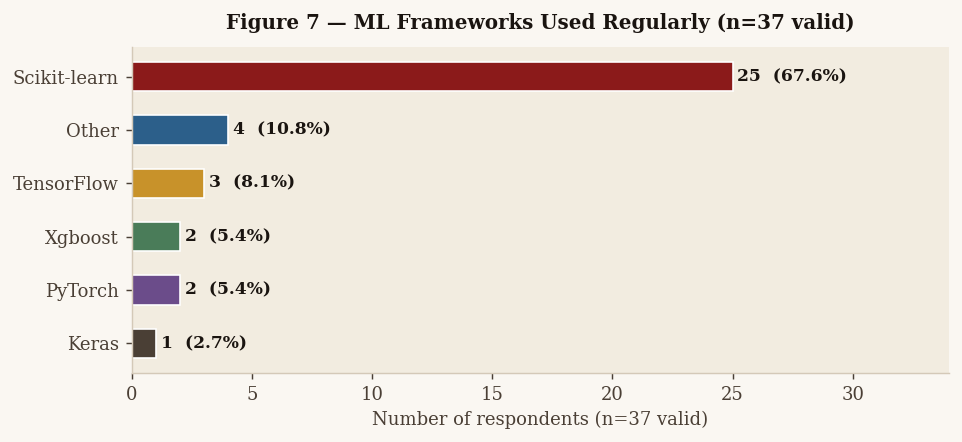

In [24]:
fw_plot  = tbl_framework.dropna().head(8)
fw_labels = fw_plot.index.tolist()
fw_values = fw_plot['Count'].tolist()
fw_pcts   = fw_plot['Percent (%)'].tolist()
fw_colors = PALETTE[:len(fw_labels)]

fig, ax = plt.subplots(figsize=(7.5, 3.5))
bars = ax.barh(fw_labels, fw_values, color=fw_colors,
               edgecolor='white', linewidth=0.9, height=0.55)

for bar, v, p in zip(bars, fw_values, fw_pcts):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{int(v)}  ({p}%)',
            va='center', fontsize=9.5, color=INK, fontweight='bold')

ax.set_xlabel('Number of respondents (n=37 valid)', fontsize=10)
ax.set_title('Figure 7 — ML Frameworks Used Regularly (n=37 valid)',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_xlim(0, max(fw_values) + 9)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.invert_yaxis()

plt.tight_layout()
save_fig('fig7_ml_frameworks')

### Figure 8: Machine Learning Experience

  Saved → figures/fig8_ml_experience.png


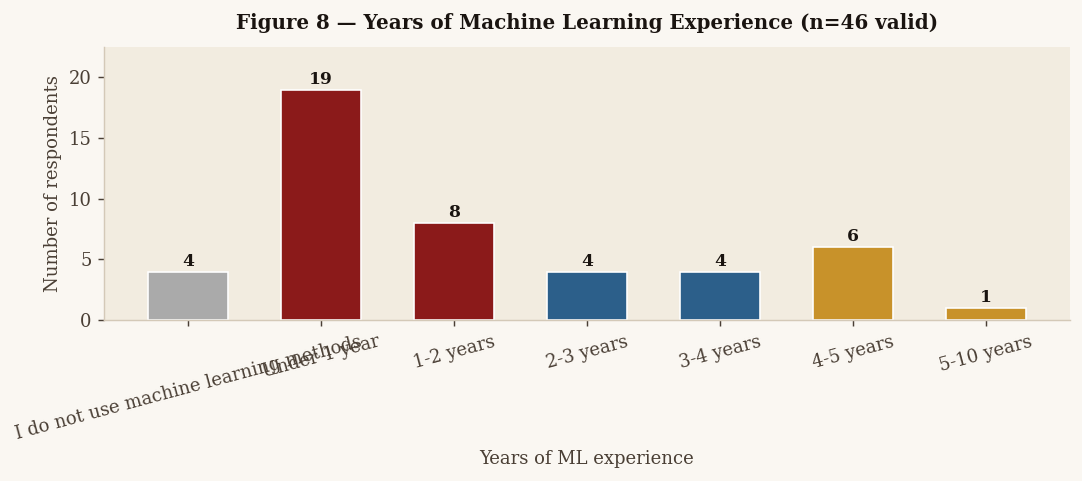

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))

ml_plot   = tbl_yr_ml.dropna()
labels_ml = ml_plot.index.tolist()
values_ml = ml_plot['Count'].tolist()
colors_ml = [CG, C1, C1, C2, C2, C3, C3][:len(labels_ml)]

bars = ax.bar(labels_ml, values_ml, color=colors_ml,
              width=0.6, edgecolor='white', linewidth=0.9)

for bar, v in zip(bars, values_ml):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(v)), ha='center', va='bottom',
            fontsize=9.5, color=INK, fontweight='bold')

ax.set_ylabel('Number of respondents', fontsize=10)
ax.set_xlabel('Years of ML experience', fontsize=10)
ax.set_title('Figure 8 — Years of Machine Learning Experience (n=46 valid)',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_ylim(0, max(values_ml) + 3.5)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('fig8_ml_experience')

### Figure 9: Industry Sectors (employed respondents)

  Saved → figures/fig9_industry.png


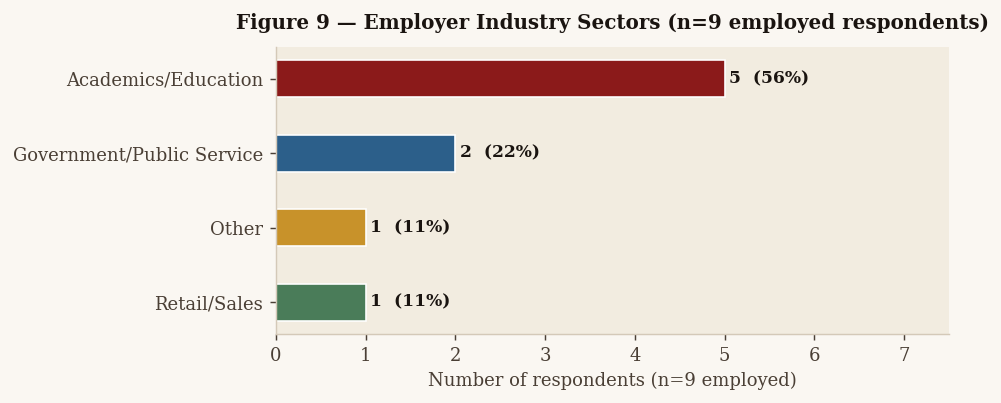

In [26]:
ind_plot   = tbl_industry.dropna()
ind_labels = ind_plot.index.tolist()
ind_values = ind_plot['Count'].tolist()
ind_colors = PALETTE[:len(ind_labels)]

fig, ax = plt.subplots(figsize=(7.5, 3.2))
bars = ax.barh(ind_labels, ind_values, color=ind_colors,
               edgecolor='white', linewidth=0.9, height=0.5)

for bar, v in zip(bars, ind_values):
    pct = v / sum(ind_values) * 100
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{int(v)}  ({pct:.0f}%)',
            va='center', fontsize=9.5, color=INK, fontweight='bold')

ax.set_xlabel('Number of respondents (n=9 employed)', fontsize=10)
ax.set_title('Figure 9 — Employer Industry Sectors (n=9 employed respondents)',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_xlim(0, max(ind_values) + 2.5)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.invert_yaxis()

plt.tight_layout()
save_fig('fig9_industry')

### Figure 10: Employer Machine Learning Adoption

  Saved → figures/fig10_employer_ml.png


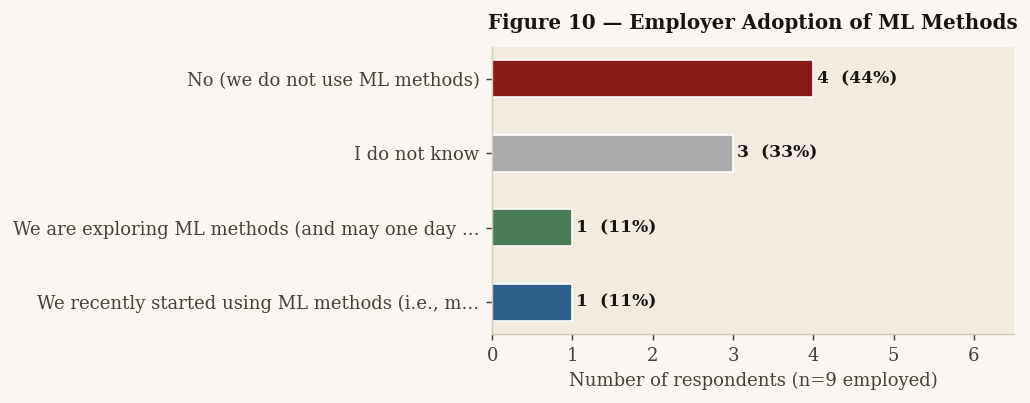

In [27]:
eml_plot   = tbl_employer_ml.dropna()
eml_labels = [l[:45] + ('...' if len(l)>45 else '') for l in eml_plot.index.tolist()]
eml_values = eml_plot['Count'].tolist()
eml_colors = [C1, CG, C4, C2][:len(eml_labels)]

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(eml_labels, eml_values, color=eml_colors,
               edgecolor='white', linewidth=0.9, height=0.5)

for bar, v in zip(bars, eml_values):
    pct = v / sum(eml_values) * 100
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{int(v)}  ({pct:.0f}%)',
            va='center', fontsize=9.5, color=INK, fontweight='bold')

ax.set_xlabel('Number of respondents (n=9 employed)', fontsize=10)
ax.set_title('Figure 10 — Employer Adoption of ML Methods',
             fontsize=11, color=INK, pad=10, fontweight='bold')
ax.set_xlim(0, max(eml_values) + 2.5)
ax.set_facecolor(WARM)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.invert_yaxis()

plt.tight_layout()
save_fig('fig10_employer_ml')

## Non-Response Summary Table

In [28]:
# Summary of missing values for the report's quality-control section
missing_summary = pd.DataFrame({
    'Variable'        : ['salary_usd', 'company_size', 'job_title',
                         'employer_uses_ml', 'education', 'years_coding'],
    'Missing (n)'     : [54, 53, 51, 53, 5, 6],
    'Missing (%)'     : [87, 85, 82, 85, 8, 10],
    'Probable cause'  : [
        'Sensitive; many students have no income',
        'Not applicable to students',
        'Not applicable to students',
        'Not applicable to students',
        'Uncertainty about planned pathway',
        'Difficulty accurately self-assessing',
    ]
})

# Verify against actual DataFrame
for var in ['salary_usd','company_size','job_title','employer_uses_ml','education','years_coding']:
    actual = df[var].isnull().sum()
    print(f"{var:25s}  missing={actual:2d}  ({actual/len(df)*100:.0f}%)")

print()
missing_summary

salary_usd                 missing=54  (87%)
company_size               missing=53  (85%)
job_title                  missing=51  (82%)
employer_uses_ml           missing=53  (85%)
education                  missing= 5  (8%)
years_coding               missing= 6  (10%)



,Variable,Missing (n),Missing (%),Probable cause
0,salary_usd,54,87,Sensitive; many students have no income
1,company_size,53,85,Not applicable to students
2,job_title,51,82,Not applicable to students
3,employer_uses_ml,53,85,Not applicable to students
4,education,5,8,Uncertainty about planned pathway
5,years_coding,6,10,Difficulty accurately self-assessing


## Final Statistics Summary

In [29]:
print('='*55)
print('  SURVEY REPORT — KEY STATISTICS SUMMARY')
print('='*55)
print(f'  Total respondents       : {len(df)}')
print(f'  Total variables         : {len(df.columns)}')
print()

n_male    = (df['gender']=='Man').sum()
n_female  = (df['gender']=='Woman').sum()
print(f'  Gender — Male           : {n_male} ({n_male/len(df)*100:.0f}%)')
print(f'  Gender — Female         : {n_female} ({n_female/len(df)*100:.0f}%)')
print()

n_student = (df['is_student']=='Yes').sum()
print(f'  Currently students      : {n_student} ({n_student/len(df)*100:.0f}%)')
print()

n_python   = (df_raw.iloc[:,10].str.strip() == 'Python').sum()
print(f'  Use Python              : {n_python} ({n_python/50*100:.0f}% of valid lang responses)')
print()

n_sklearn  = (df['ml_framework']=='Scikit-learn').sum()
print(f'  Use Scikit-learn        : {n_sklearn} ({n_sklearn/37*100:.0f}% of valid fw responses)')
print()

n_gpu = (df['uses_gpu'].notna()).sum()
print(f'  Use GPU                 : {n_gpu} ({n_gpu/len(df)*100:.0f}%)')
print()

n_coursera = (df['platform_coursera'].notna()).sum()
print(f'  Learn on Coursera       : {n_coursera} ({n_coursera/len(df)*100:.0f}%)')
print()

under30_labels = ['18-21','22-24','25-29']
n_u30 = sum(tbl_age.loc[a,'Count'] for a in under30_labels if a in tbl_age.index)
print(f'  Under 30 years old      : {n_u30} ({n_u30/len(df)*100:.0f}%)')
print()

masters_phd = sum(tbl_education.loc[a,'Count']
                  for a in ["Master's degree","Doctoral degree"]
                  if a in tbl_education.index)
valid_edu = tbl_education['Count'].sum()
print(f'  Master\'s or Doctoral     : {masters_phd} ({masters_phd/valid_edu*100:.0f}% of valid edu responses)')
print('='*55)

  SURVEY REPORT — KEY STATISTICS SUMMARY
  Total respondents       : 62
  Total variables         : 43

  Gender — Male           : 44 (71%)
  Gender — Female         : 16 (26%)

  Currently students      : 46 (74%)

  Use Python              : 40 (80% of valid lang responses)

  Use Scikit-learn        : 25 (68% of valid fw responses)

  Use GPU                 : 2 (3%)

  Learn on Coursera       : 55 (89%)

  Under 30 years old      : 35 (56%)

  Master's or Doctoral     : 44 (77% of valid edu responses)


## List All Saved Figures


In [30]:
import glob
saved = sorted(glob.glob('figures/*.png'))
print(f"\n{len(saved)} figures saved:\n")
for f in saved:
    print(' ', f)


10 figures saved:

  figures/fig10_employer_ml.png
  figures/fig1_age_distribution.png
  figures/fig2_gender_student.png
  figures/fig3_education.png
  figures/fig4_learning_platforms.png
  figures/fig5_years_coding.png
  figures/fig6_languages.png
  figures/fig7_ml_frameworks.png
  figures/fig8_ml_experience.png
  figures/fig9_industry.png
